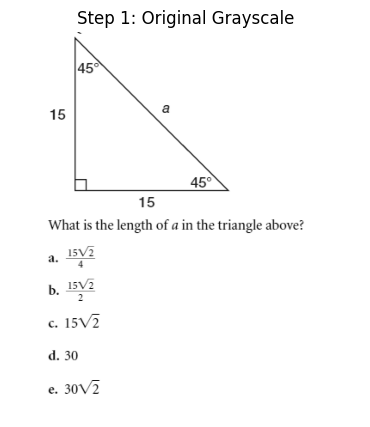

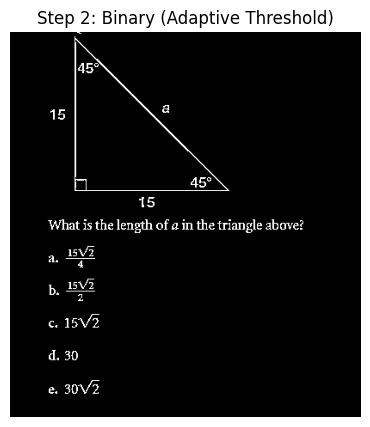

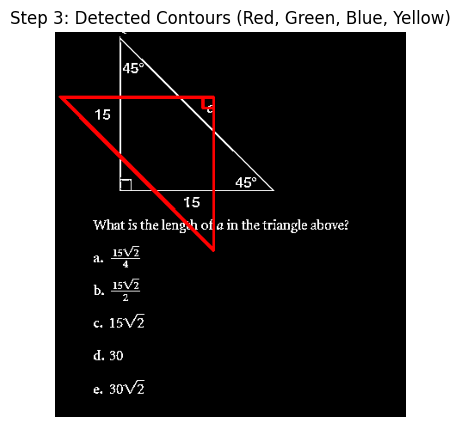

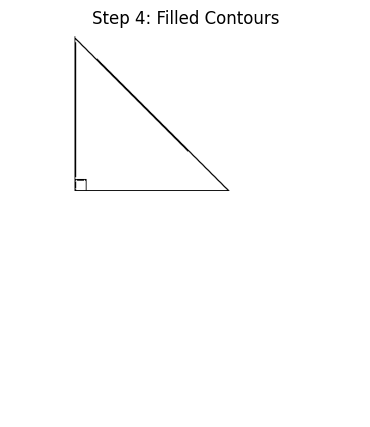

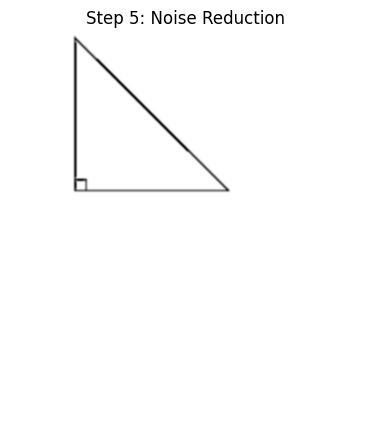

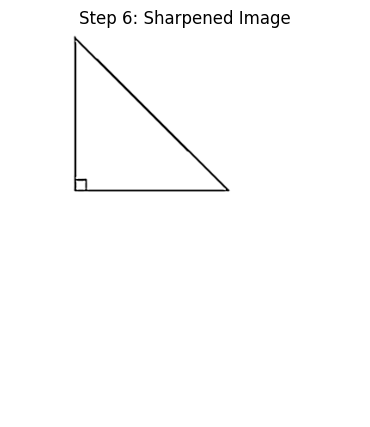

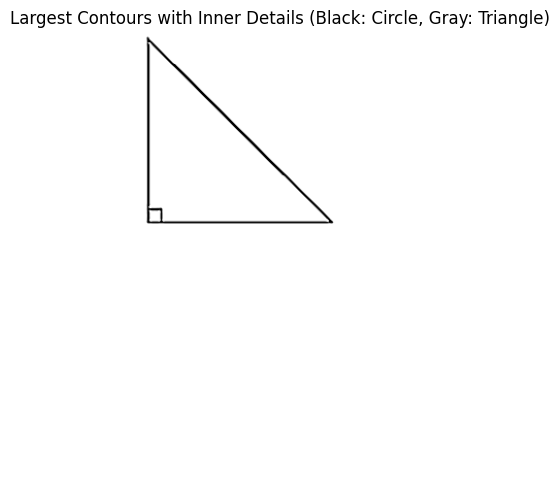

Largest contour size: 1021, Second largest: None


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", image)

    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 2: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_binary.png", binary)

    return binary

def find_contours_manual(binary):
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check all 8 neighbors for a more complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    # Sort contours by area (number of points)
    contours.sort(key=len, reverse=True)
    return contours[:4]  # Return top 2 largest contours

def detect_largest_contour(image_path):
    binary = preprocess_image(image_path)

    contours = find_contours_manual(binary)
    if not contours:
        print("No contours found.")
        return

    if len(contours) < 1:
        print("No valid contours found.")
        return

    # Step 3: Visualize detected contours on binary image with color
    # Convert grayscale to RGB for color display
    contour_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]  # Red, Green, Blue, Yellow
    for idx, contour in enumerate(contours):
        if idx < len(colors):
            coords = np.array(contour, dtype=np.int32)
            cv2.polylines(contour_image, [coords], isClosed=True, color=colors[idx], thickness=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_image)
    plt.title("Step 3: Detected Contours (Red, Green, Blue, Yellow)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step3_detected_contours.png", contour_image)

    # Step 4: Create and fill contours on a new canvas
    outline_image = np.ones_like(binary) * 255  # White background
    if contours[0]:
        coords = np.array(contours[0], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 0  # Fill with black
    if len(contours) > 1 and contours[1]:
        coords = np.array(contours[1], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 128  # Fill with gray
    plt.figure(figsize=(5, 5))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Step 4: Filled Contours")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step4_filled_contours.png", outline_image)

    # Step 5: Noise Reduction using Gaussian Blur
    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)
    plt.figure(figsize=(5, 5))
    plt.imshow(noise_reduced, cmap='gray')
    plt.title("Step 5: Noise Reduction")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step5_noise_reduced.png", noise_reduced)

    # Step 6: Sharpen the image
    kernel = np.array([[-1, -1, -1],
                      [-1, 9, -1],
                      [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)
    plt.figure(figsize=(5, 5))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Step 6: Sharpened Image")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step6_sharpened.png", sharpened)

    plt.figure(figsize=(6, 6))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Largest Contours with Inner Details (Black: Circle, Gray: Triangle)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("largest_contours_with_inner_details.png", sharpened)

    print(f"Largest contour size: {len(contours[0])}, Second largest: {len(contours[1]) if len(contours) > 1 else 'None'}")

#image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\013.png"
image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\039.png"

detect_largest_contour(image_path)